# Random Forest Classifier


In [71]:
# Load importanat libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from warnings import filterwarnings
filterwarnings('ignore')

In [72]:
#Load the Dataset
data = pd.read_csv('heart.csv')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [73]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Features:
* age - Patient age
* Sex - Gender 1 -> Male 0-> Female
* CP -> chest pain
* trestbps -> resting bloog pressure(in mm/hg)
* chol -> blood cholestrol level
* fbs -> Fasting blood sugar
* restecg -> heart activity while resting
* thalach -> Max heart rate while excercise
* exang -> Is there any pain during excercise
* oldpeak -> Electrical activities of heart
* slope -> 0 -> upslope , 1-> flat, 2 -> downslope
* ca -> whether in vessels there are blockage or vessels is being narrow down or not
* Thal -> Thallium test (Permanent damage or healthy heart)
* Target -> Heart disease present or not

In [74]:
data.shape      # 303-Rows & 14 columns(Features)

(303, 14)

In [75]:
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [76]:
# Info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [77]:
# Statistical Summary of the data
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [78]:
# Check the Null Values
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


No null values present in this dataset

In [79]:
# Check duplicate null values
data.duplicated().sum()     # 1 duplicate value present in this data set

np.int64(1)

In [80]:
fig = px.pie(data,names='target',title='<b>Heart Disease</b>')
fig.update_layout(height=400,width=500, paper_bgcolor='Floralwhite')
fig.show()

In [81]:
data[(data['chol']>=300)&(data['age']>=40)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
16,58,0,2,120,340,0,1,172,0,0.0,2,0,2,1
25,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
28,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
36,54,0,2,135,304,1,1,170,0,0.0,2,0,2,1
39,65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
40,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
45,52,1,1,120,325,0,1,172,0,0.2,2,0,2,1
51,66,1,0,120,302,0,0,151,0,0.4,1,0,2,1
59,57,0,0,128,303,0,0,159,0,0.0,2,1,2,1


In [82]:
data['target'].value_counts()

,count
target,
1,165
0,138


In [83]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: >

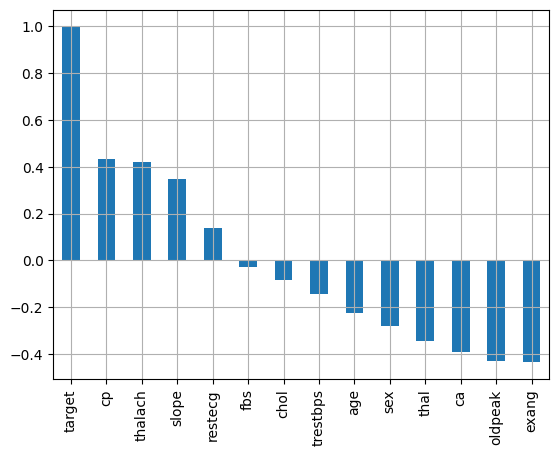

In [96]:
data.corr()['target'].sort_values(ascending=False).plot(kind='bar',grid=True)

In [97]:
data=data.drop('fbs',axis=1)

In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   restecg   303 non-null    int64  
 6   thalach   303 non-null    int64  
 7   exang     303 non-null    int64  
 8   oldpeak   303 non-null    float64
 9   slope     303 non-null    int64  
 10  ca        303 non-null    int64  
 11  thal      303 non-null    int64  
 12  target    303 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 30.9 KB


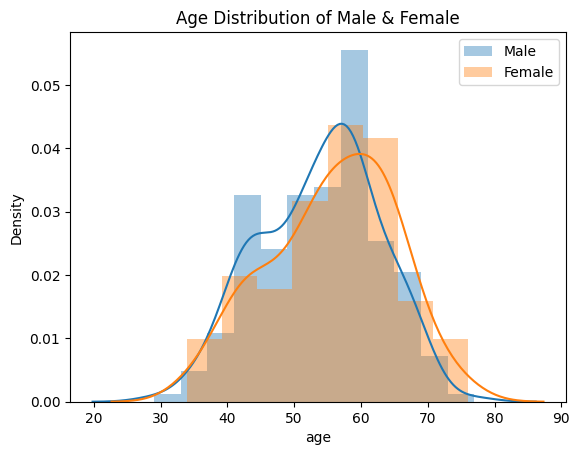

In [109]:
sns.distplot(data[data['sex']==1]['age'],label='Male')
sns.distplot(data[data['sex']==0]['age'],label='Female')
plt.legend()
plt.title('Age Distribution of Male & Female')
plt.show()



In [107]:
fig=px.imshow(data.corr(),text_auto=True,title='<b>Correlation between Features</b>')
fig.update_layout(
    width=800,  # Set the width of the plot
    height=700, # Set the height of the plot
    xaxis_tickangle=-90, # Rotate x-axis labels for better readability
)

# Show the plot
fig.show()


# Model Building

In [110]:
X=data.drop('target',axis=1)
Y=data['target']


In [112]:
X

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,0,150,0,2.3,0,0,1
1,37,1,2,130,250,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,172,0,1.4,2,0,2
3,56,1,1,120,236,1,178,0,0.8,2,0,2
4,57,0,0,120,354,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,1,123,1,0.2,1,0,3
299,45,1,3,110,264,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,141,0,3.4,1,2,3
301,57,1,0,130,131,1,115,1,1.2,1,1,3


In [113]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [114]:
X_train

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,111,1,0.8,2,0,3
196,46,1,2,150,231,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,1,163,0,0.6,1,1,3
71,51,1,2,94,227,1,154,1,0.0,2,1,3
106,69,1,3,160,234,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,144,0,0.8,2,0,3


In [115]:
X_test

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,150,1,1.9,1,2,3
60,71,0,2,110,265,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,146,0,2.0,1,3,3
104,50,1,2,129,196,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,142,1,2.8,1,2,3


In [116]:
Y_train

,target
132,1
202,0
196,0
75,1
176,0
...,...
188,0
71,1
106,1
270,0


In [119]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()

In [120]:
model.fit(X_train,Y_train)

RandomForestClassifier()

In [121]:
y_pred=model.predict(X_test)

In [129]:
from sklearn.metrics import *
print('Accuracy:',accuracy_score(Y_test,y_pred)*100)



Accuracy: 85.24590163934425


In [126]:
print('confusion_matrix:',confusion_matrix(Y_test,y_pred))

confusion_matrix: [[24  5]
 [ 4 28]]


In [135]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

